In [1]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from itertools import combinations

In [2]:
def plot_cosine_similarities_histogram(cos_similarities, save_path, title, xlabel, ylabel, log_scale=False, y_max=None):
    """
    Plot and save a histogram of cosine similarities.

    Args:
        cos_similarities (list): List of cosine similarities to plot.
        save_path (str): Path to save the histogram image.
        title (str): Title of the histogram.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        log_scale (bool): Whether to plot the histogram on a logarithmic scale. Default is False.
        y_max (float, optional): Maximum limit for the y-axis. Default is None.
    """
    plt.figure(figsize=(10, 5))
    plt.hist(cos_similarities, bins=50, rwidth=0.9, log=log_scale, range=(0.0, 1.0))  # Set x-axis range from 0.0 to 1.0
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if y_max is not None:
        plt.ylim(0, y_max if not log_scale else 1)
    plt.savefig(save_path)
    plt.show()
    plt.close()
    print(f'Saved histogram at {save_path}')

def compute_cosine_similarities(user_representations):
    """
    Compute cosine similarities for all users against the mean representation.

    Args:
        user_representations (np.ndarray): Array of user representations.

    Returns:
        list: Cosine similarities for all users.
    """
    mean_representation_all = np.mean(user_representations, axis=0)
    cos_similarities_all = []
    for user_rep in user_representations:
        cos_sim = np.sum(user_rep * mean_representation_all, axis=1) / (np.linalg.norm(user_rep, axis=1) * np.linalg.norm(mean_representation_all))
        cos_similarities_all.extend(cos_sim)
    return cos_similarities_all

def plot_histograms_from_file(pickle_file_path, save_dir, y_max=None):
    """
    Load user representations from a pickle file, compute cosine similarities,
    and plot histograms for all users.

    Args:
        pickle_file_path (str): Path to the pickle file containing user representations.
        save_dir (str): Directory to save the histograms.
        y_max (float, optional): Maximum limit for the y-axis. Default is None.

    Returns:
        tuple: Paths to the saved histograms for all users.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Load user representations
    with open(pickle_file_path, 'rb') as f:
        user_representations = pickle.load(f)
    if not isinstance(user_representations, np.ndarray):
        user_representations = np.array(user_representations)

    # Compute cosine similarities for all users
    cos_similarities_all = compute_cosine_similarities(user_representations)
    
    # Plot histogram for all users (linear scale)
    all_users_path = os.path.join(save_dir, 'cosine_similarities_all_users.png')
    plot_cosine_similarities_histogram(cos_similarities_all, all_users_path, 
                                       'Cosine Similarities of User Representations (All Users)', 
                                       'Cosine Similarity', 'Frequency', log_scale=False, y_max=y_max)

    # Plot histogram for all users (logarithmic scale)
    all_users_log_path = os.path.join(save_dir, 'cosine_similarities_all_users_log.png')
    plot_cosine_similarities_histogram(cos_similarities_all, all_users_log_path, 
                                       'Cosine Similarities of User Representations (All Users) - Log Scale', 
                                       'Cosine Similarity', 'Frequency (Log Scale)', log_scale=True, y_max=y_max)

    return all_users_path, all_users_log_path


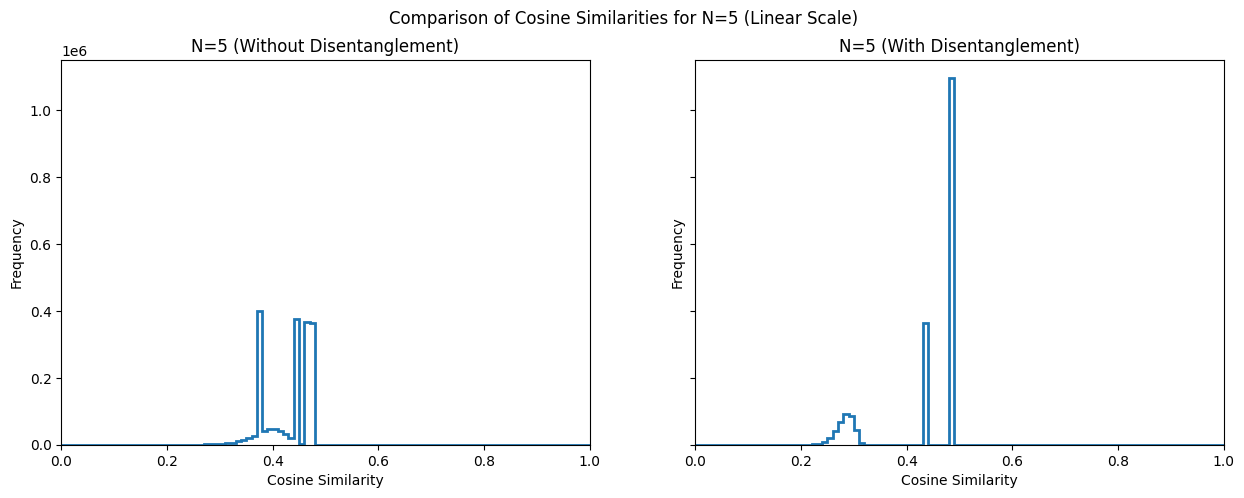

Saved separate histograms for N=5 (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/separate_cosine_similarities_N5_linear_scale.png


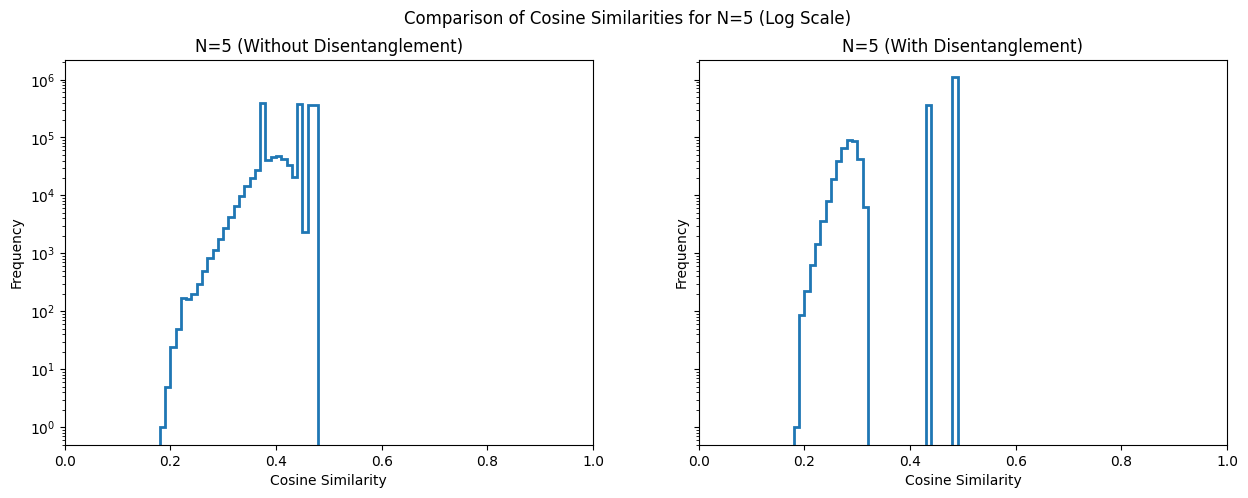

Saved separate histograms for N=5 (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/separate_cosine_similarities_N5_log_scale.png


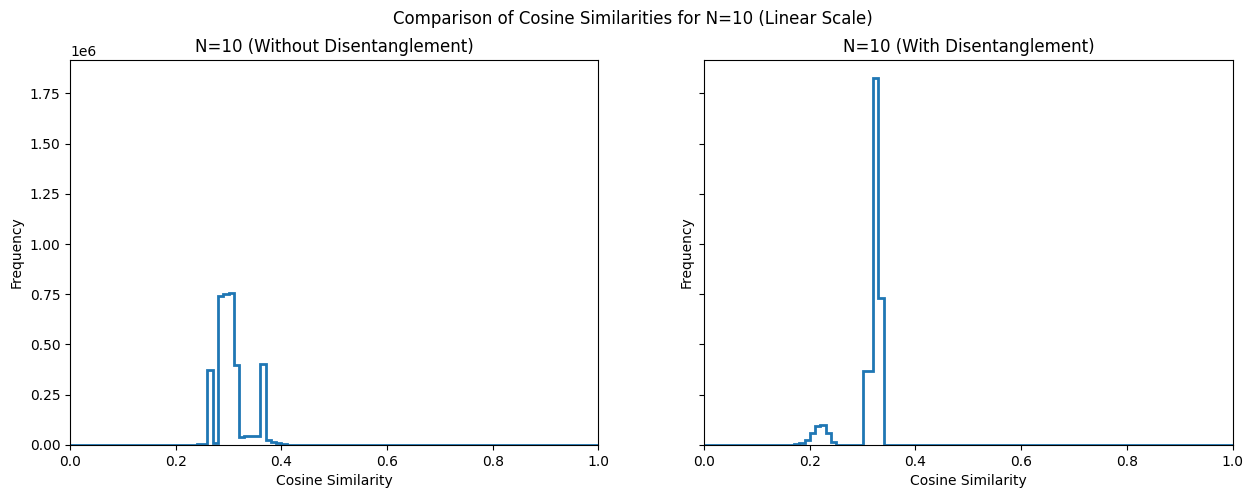

Saved separate histograms for N=10 (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/separate_cosine_similarities_N10_linear_scale.png


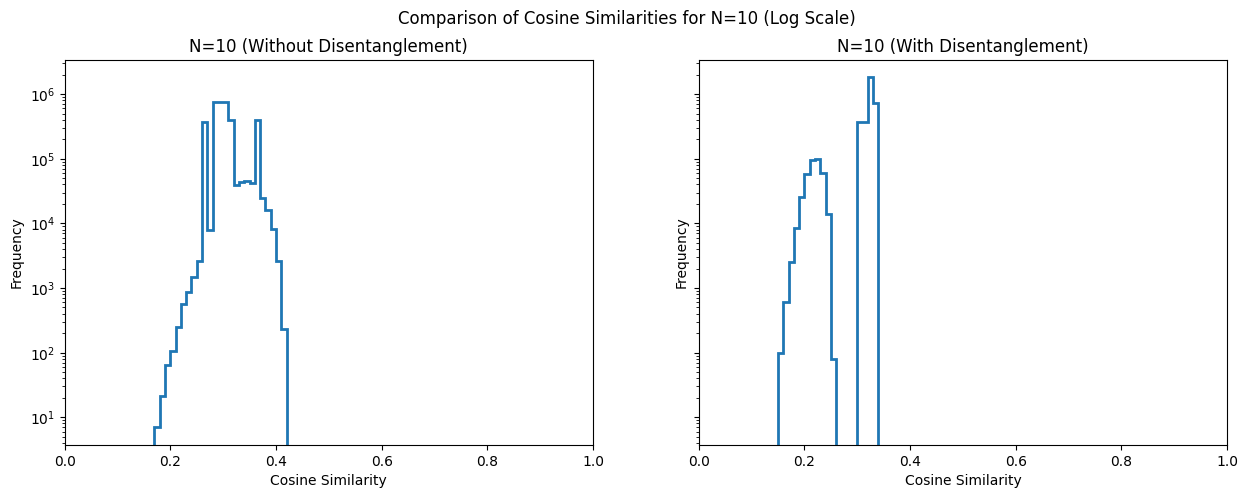

Saved separate histograms for N=10 (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/separate_cosine_similarities_N10_log_scale.png


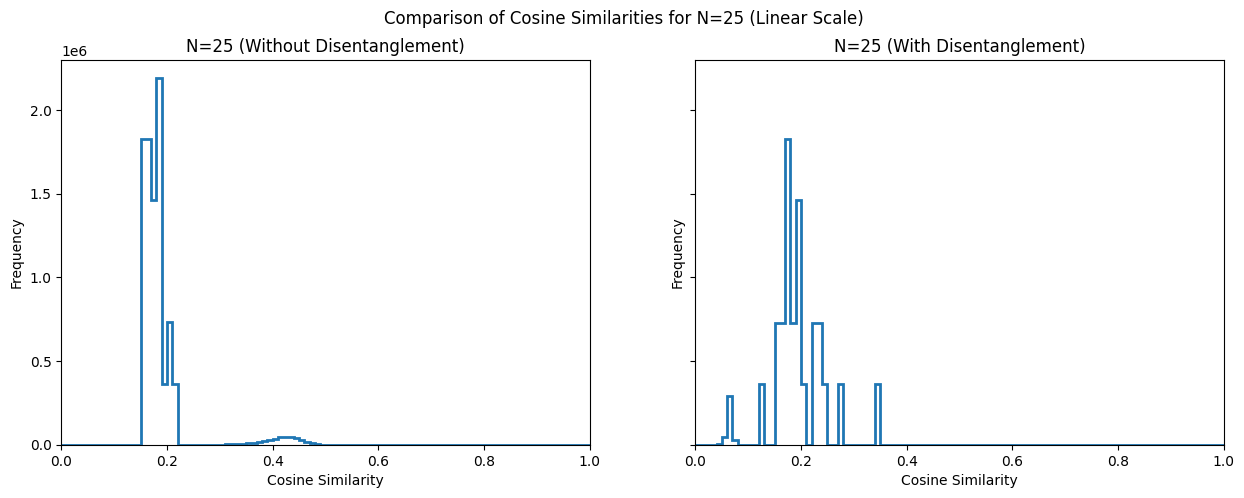

Saved separate histograms for N=25 (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/separate_cosine_similarities_N25_linear_scale.png


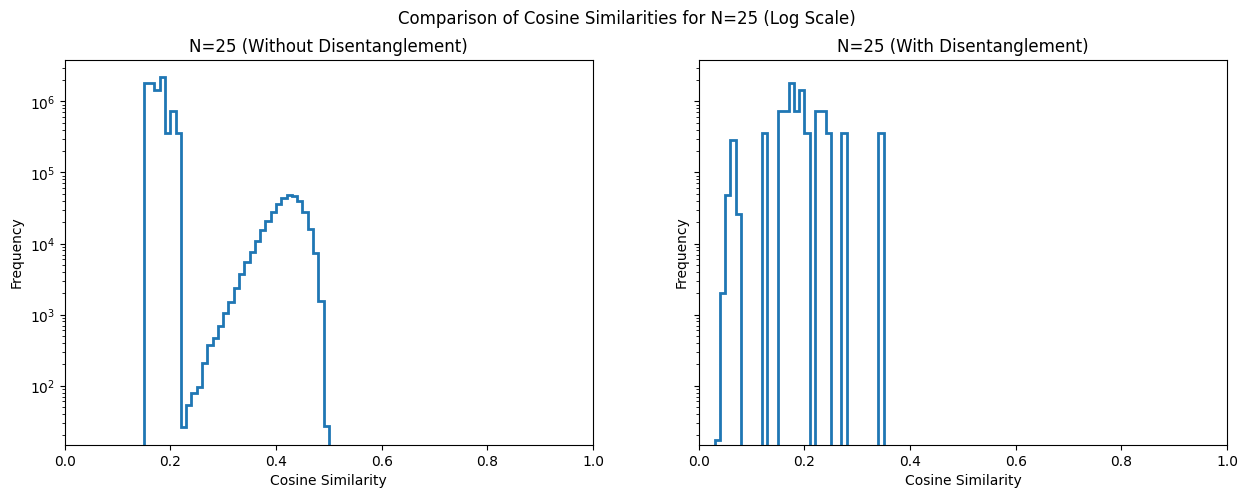

Saved separate histograms for N=25 (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/separate_cosine_similarities_N25_log_scale.png


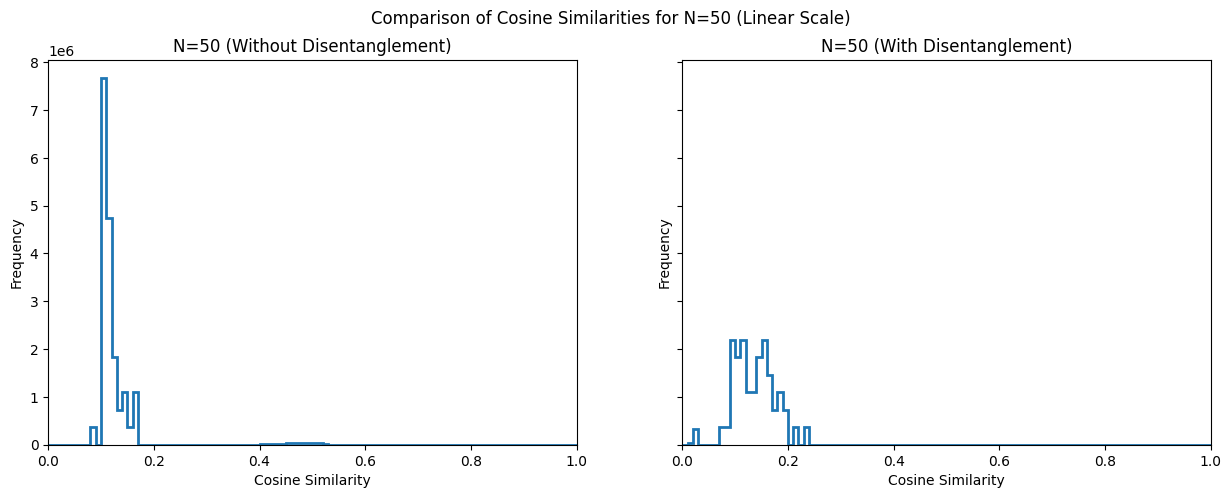

Saved separate histograms for N=50 (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/separate_cosine_similarities_N50_linear_scale.png


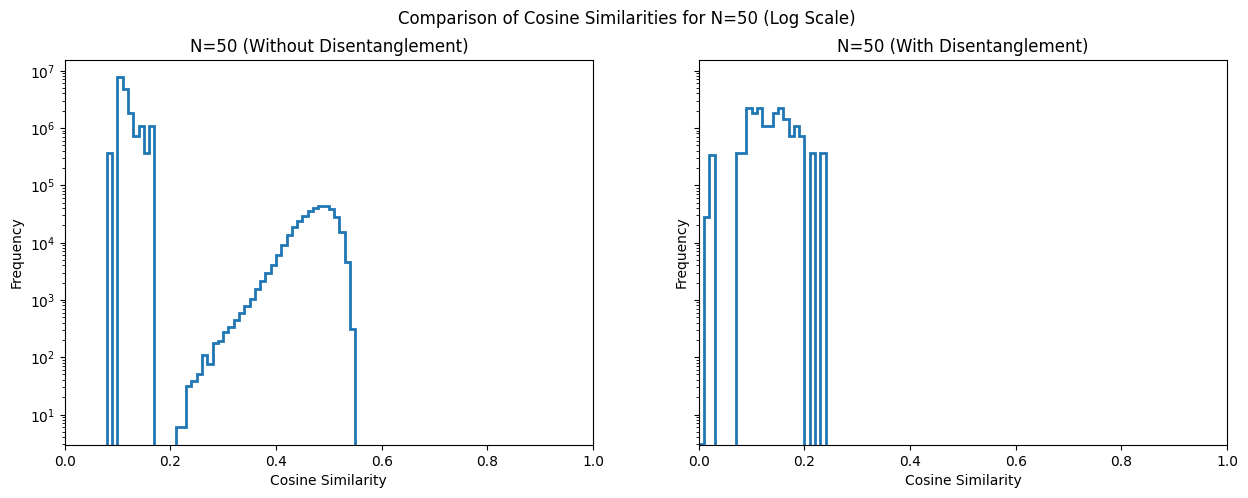

Saved separate histograms for N=50 (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/separate_cosine_similarities_N50_log_scale.png


In [3]:
def plot_cosine_similarities_histogram(ax, cos_similarities, title, xlabel, ylabel, log_scale=False):
    """
    Plot a histogram of cosine similarities on the provided axis using 'step' histtype for more detailed visualization.

    Args:
        ax (matplotlib.axes.Axes): The axis on which to plot the histogram.
        cos_similarities (list): List of cosine similarities to plot.
        title (str): Title of the histogram.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        log_scale (bool): Whether to plot the histogram on a logarithmic scale. Default is False.
    """
    ax.hist(cos_similarities, bins=100, histtype='step', linewidth=2, log=log_scale, range=(0.0, 1.0))  # Increased bins for finer detail
    ax.set_xlim(0.0, 1.0)  # Ensure the x-axis goes from 0 to 1.0
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def compute_cosine_similarities(user_representations):
    """
    Compute cosine similarities for all users against the mean representation.

    Args:
        user_representations (np.ndarray): Array of user representations.

    Returns:
        list: Cosine similarities for all users.
    """
    mean_representation_all = np.mean(user_representations, axis=0)
    cos_similarities_all = []
    for user_rep in user_representations:
        cos_sim = np.sum(user_rep * mean_representation_all, axis=1) / (np.linalg.norm(user_rep, axis=1) * np.linalg.norm(mean_representation_all))
        cos_similarities_all.extend(cos_sim)
    return cos_similarities_all

def plot_side_by_side_histograms(pickle_file_path_without_disentanglement, pickle_file_path_with_disentanglement, save_dir, N_value):
    """
    Load user representations from two pickle files (with and without disentanglement),
    compute cosine similarities, and plot histograms side by side for comparison.

    Args:
        pickle_file_path_without_disentanglement (str): Path to the pickle file without disentanglement.
        pickle_file_path_with_disentanglement (str): Path to the pickle file with disentanglement.
        save_dir (str): Directory to save the histograms.
        N_value (int): The value of N (e.g., 5, 10, 25, 50).

    Returns:
        tuple: Paths to the saved linear and log scale histograms.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Plot linear scale histogram
    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for ax, pickle_file_path, label, color in zip(
        axs,
        [pickle_file_path_without_disentanglement, pickle_file_path_with_disentanglement],
        [f'N={N_value} (Without Disentanglement)', f'N={N_value} (With Disentanglement)'],
        ['blue', 'orange']
    ):
        # Load user representations
        with open(pickle_file_path, 'rb') as f:
            user_representations = pickle.load(f)
        if not isinstance(user_representations, np.ndarray):
            user_representations = np.array(user_representations)

        # Compute cosine similarities for all users
        cos_similarities = compute_cosine_similarities(user_representations)

        # Plot histogram of cosine similarities on a linear scale
        plot_cosine_similarities_histogram(ax, cos_similarities, label, 'Cosine Similarity', 'Frequency', log_scale=False)
    
    plt.suptitle(f'Comparison of Cosine Similarities for N={N_value} (Linear Scale)')
    combined_histogram_path_linear = os.path.join(save_dir, f'separate_cosine_similarities_N{N_value}_linear_scale.png')
    plt.savefig(combined_histogram_path_linear)
    plt.show()
    plt.close()
    print(f'Saved separate histograms for N={N_value} (Linear Scale) at {combined_histogram_path_linear}')

    # Plot log scale histogram
    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for ax, pickle_file_path, label, color in zip(
        axs,
        [pickle_file_path_without_disentanglement, pickle_file_path_with_disentanglement],
        [f'N={N_value} (Without Disentanglement)', f'N={N_value} (With Disentanglement)'],
        ['blue', 'orange']
    ):
        # Load user representations
        with open(pickle_file_path, 'rb') as f:
            user_representations = pickle.load(f)
        if not isinstance(user_representations, np.ndarray):
            user_representations = np.array(user_representations)

        # Compute cosine similarities for all users
        cos_similarities = compute_cosine_similarities(user_representations)

        # Plot histogram of cosine similarities on a log scale
        plot_cosine_similarities_histogram(ax, cos_similarities, label, 'Cosine Similarity', 'Frequency', log_scale=True)
    
    plt.suptitle(f'Comparison of Cosine Similarities for N={N_value} (Log Scale)')
    combined_histogram_path_log = os.path.join(save_dir, f'separate_cosine_similarities_N{N_value}_log_scale.png')
    plt.savefig(combined_histogram_path_log)
    plt.show()
    plt.close()
    print(f'Saved separate histograms for N={N_value} (Log Scale) at {combined_histogram_path_log}')

    return combined_histogram_path_linear, combined_histogram_path_log

# Example Usage

# N=5
combined_histogram_paths_5 = plot_side_by_side_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots',
    N_value=5
)

# N=10
combined_histogram_paths_10 = plot_side_by_side_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots',
    N_value=10
)

# N=25
combined_histogram_paths_25 = plot_side_by_side_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots',
    N_value=25
)

# N=50
combined_histogram_paths_50 = plot_side_by_side_histograms(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots',
    N_value=50
)


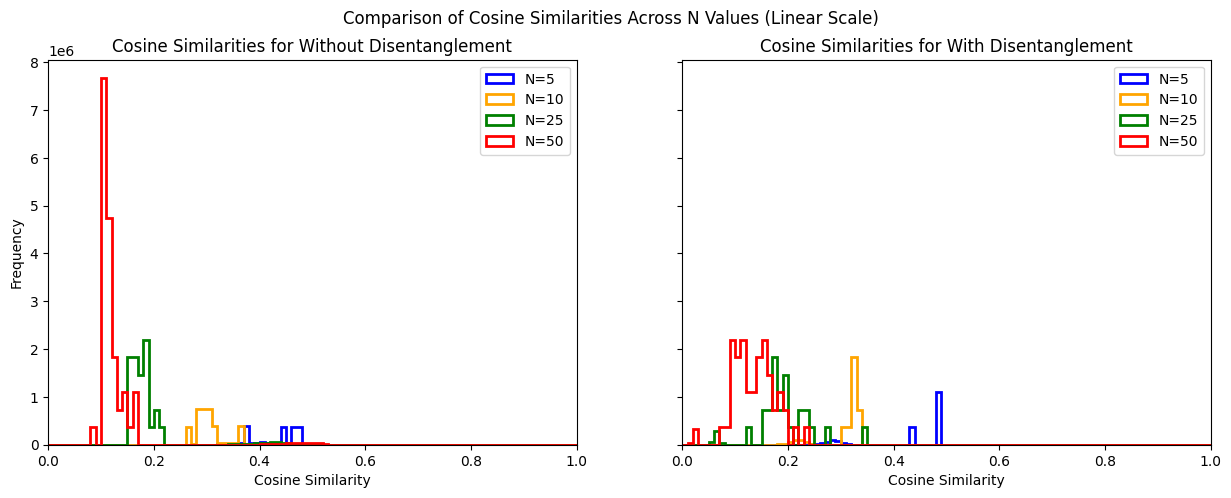

Saved combined histogram for all N values (Linear Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/all_N_cosine_similarities_linear_scale.png


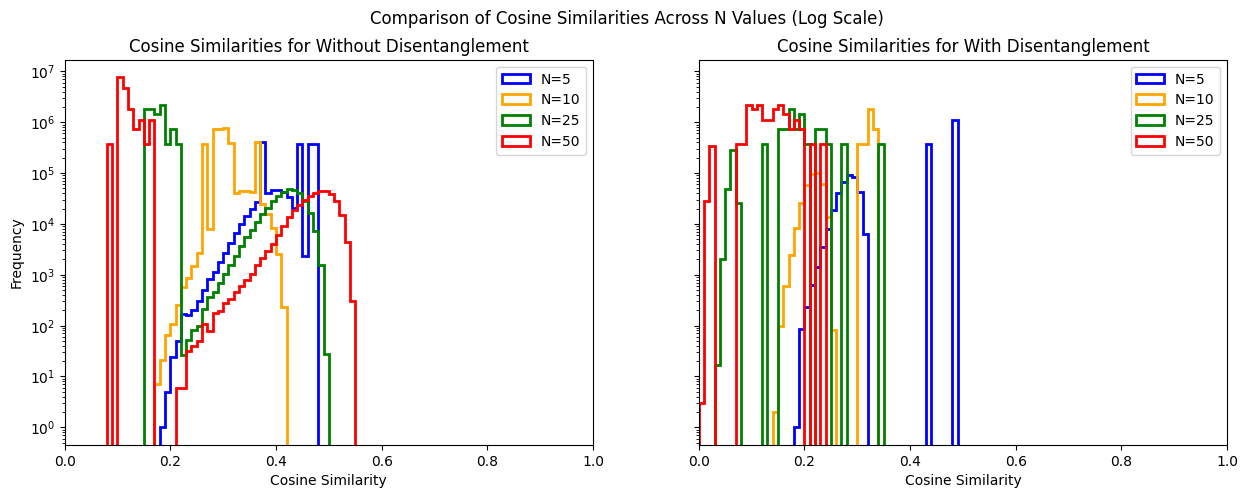

Saved combined histogram for all N values (Log Scale) at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots/all_N_cosine_similarities_log_scale.png


In [8]:
def plot_cosine_similarities_histogram(ax, cos_similarities, label, color, log_scale=False):
    """
    Plot a histogram of cosine similarities on the provided axis using 'step' histtype for more detailed visualization.

    Args:
        ax (matplotlib.axes.Axes): The axis on which to plot the histogram.
        cos_similarities (list): List of cosine similarities to plot.
        label (str): Label for the histogram (used in the legend).
        color (str): Color of the histogram outline.
        log_scale (bool): Whether to plot the histogram on a logarithmic scale. Default is False.
    """
    ax.hist(cos_similarities, bins=100, histtype='step', linewidth=2, color=color, label=label, log=log_scale, range=(0.0, 1.0))  # Increased bins for finer detail
    ax.set_xlim(0.0, 1.0)  # Ensure the x-axis goes from 0 to 1.0

def compute_cosine_similarities(user_representations):
    """
    Compute cosine similarities for all users against the mean representation.

    Args:
        user_representations (np.ndarray): Array of user representations.

    Returns:
        list: Cosine similarities for all users.
    """
    mean_representation_all = np.mean(user_representations, axis=0)
    cos_similarities_all = []
    for user_rep in user_representations:
        cos_sim = np.sum(user_rep * mean_representation_all, axis=1) / (np.linalg.norm(user_rep, axis=1) * np.linalg.norm(mean_representation_all))
        cos_similarities_all.extend(cos_sim)
    return cos_similarities_all

def plot_all_N_histograms(pickle_files, labels, save_dir, log_scale=False):
    """
    Plot all N histograms in one plot for "Without Disentanglement" and one for "With Disentanglement."

    Args:
        pickle_files (dict): A dictionary with keys "Without Disentanglement" and "With Disentanglement",
                             each containing a list of paths to pickle files for different N values.
        labels (list): A list of labels corresponding to each N value.
        save_dir (str): Directory to save the plots.
        log_scale (bool): Whether to plot the histogram on a logarithmic scale. Default is False.
    """
    os.makedirs(save_dir, exist_ok=True)

    colors = ['blue', 'orange', 'green', 'red']  # Colors for each N value

    fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for ax, key, title in zip(
        axs,
        ["Without Disentanglement", "With Disentanglement"],
        ["Without Disentanglement", "With Disentanglement"]
    ):
        for i, (pickle_file, label) in enumerate(zip(pickle_files[key], labels)):
            # Load user representations
            with open(pickle_file, 'rb') as f:
                user_representations = pickle.load(f)
            if not isinstance(user_representations, np.ndarray):
                user_representations = np.array(user_representations)

            # Compute cosine similarities for all users
            cos_similarities = compute_cosine_similarities(user_representations)

            # Plot histogram of cosine similarities
            plot_cosine_similarities_histogram(ax, cos_similarities, label=label, color=colors[i], log_scale=log_scale)

        ax.set_title(f'Cosine Similarities for {title}')
        ax.set_xlabel('Cosine Similarity')
        ax.legend()

    axs[0].set_ylabel('Frequency')

    scale_type = 'Log' if log_scale else 'Linear'
    plt.suptitle(f'Comparison of Cosine Similarities Across N Values ({scale_type} Scale)')
    combined_histogram_path = os.path.join(save_dir, f'all_N_cosine_similarities_{scale_type.lower()}_scale.png')
    plt.savefig(combined_histogram_path)
    plt.show()
    plt.close()
    print(f'Saved combined histogram for all N values ({scale_type} Scale) at {combined_histogram_path}')

    return combined_histogram_path

# Example Usage

pickle_files = {
    "Without Disentanglement": [
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl'
    ],
    "With Disentanglement": [
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
        '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl'
    ]
}

labels = ['N=5', 'N=10', 'N=25', 'N=50']

# Plot without log scale
combined_histogram_path_linear = plot_all_N_histograms(
    pickle_files,
    labels,
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots',
    log_scale=False
)

# Plot with log scale
combined_histogram_path_log = plot_all_N_histograms(
    pickle_files,
    labels,
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/cosine_similarities_merged_plots',
    log_scale=True
)
